# A geodesic combing of $\mathbb{Z}*\mathbb{Z}^2$

We use $G=\langle a,b,c\mid bc=cb\rangle$ and the symmetric generating set
$S=\{a,\bar a,b,\bar b,c,\bar c\}$. The $a$-factor is $\mathbb{Z}$; the $b,c$-factor is $\mathbb{Z}^2$.

This notebook constructs the **labeled directed graph**, its **adjacency matrix $M$**, and its **component quotient**. Uppercase letters `A`, `B`, `C` denote inverses in code and are displayed with bars in figures. Every state is accepting, and $v_0$ is the initial state. The empty path represents the identity.

The combing chooses one geodesic word for each element. It does not accept every geodesic word: $cb$ is geodesic, but the chosen word for that element is $bc$.

In [19]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
from IPython.display import display, Math
import sympy as sp

%matplotlib inline
plt.ioff()
plt.rcParams.update({'figure.dpi': 130, 'font.size': 12})
np.set_printoptions(linewidth=120)

## 1. States and labeled transitions

A noninitial state $v_s$ records the last letter $s$. Reading a letter $t$ follows an edge labeled $t$ to $v_t$.

| State | Allowed next letters |
|:--|:--|
| $v_0$ | $a,\bar a,b,\bar b,c,\bar c$ |
| $v_a$ | $a,b,\bar b,c,\bar c$ |
| $v_{\bar a}$ | $\bar a,b,\bar b,c,\bar c$ |
| $v_b$ | $b,c,\bar c,a,\bar a$ |
| $v_{\bar b}$ | $\bar b,c,\bar c,a,\bar a$ |
| $v_c$ | $c,a,\bar a$ |
| $v_{\bar c}$ | $\bar c,a,\bar a$ |

Within a $\mathbb{Z}^2$ syllable, all $b$ letters precede all $c$ letters. Each generator keeps a constant sign within its run. An $a$ or $\bar a$ starts a new factor syllable, so a subsequent $b$ run is allowed again.

In [20]:
letters = ('a', 'A', 'b', 'B', 'c', 'C')
states = ['v0'] + ['v_' + s for s in letters]
idx = {v: i for i, v in enumerate(states)}
allowed = {
    'v0': 'aAbBcC',
    'v_a': 'abBcC',
    'v_A': 'AbBcC',
    'v_b': 'bcCaA',
    'v_B': 'BcCaA',
    'v_c': 'caA',
    'v_C': 'CaA',
}
transitions = {v: [(s, 'v_' + s) for s in word] for v, word in allowed.items()}
G = nx.DiGraph()
G.add_nodes_from(states)
for source, outgoing in transitions.items():
    for letter, target in outgoing:
        G.add_edge(source, target, label=letter)

letter_tex = {'a':'a', 'A':r' a^{-1}', 'b':'b', 'B':r'b^{-1}', 'c':'c', 'C':r'c^{-1}'}
state_tex = {'v0': r'v_0', **{'v_' + s: 'v_{' + t + '}' for s, t in letter_tex.items()}}
print(f'{G.number_of_nodes()} states; {G.number_of_edges()} labeled edges, including six loops.')

7 states; 32 labeled edges, including six loops.


## 2. The directed graph $\mathcal{G}$

Every arrow carries its input letter; color also identifies that letter. Paired arrows use opposite curves. Double circles indicate accepting states. The small incoming arrow marks the initial state and is not an edge of $\mathcal{G}$.

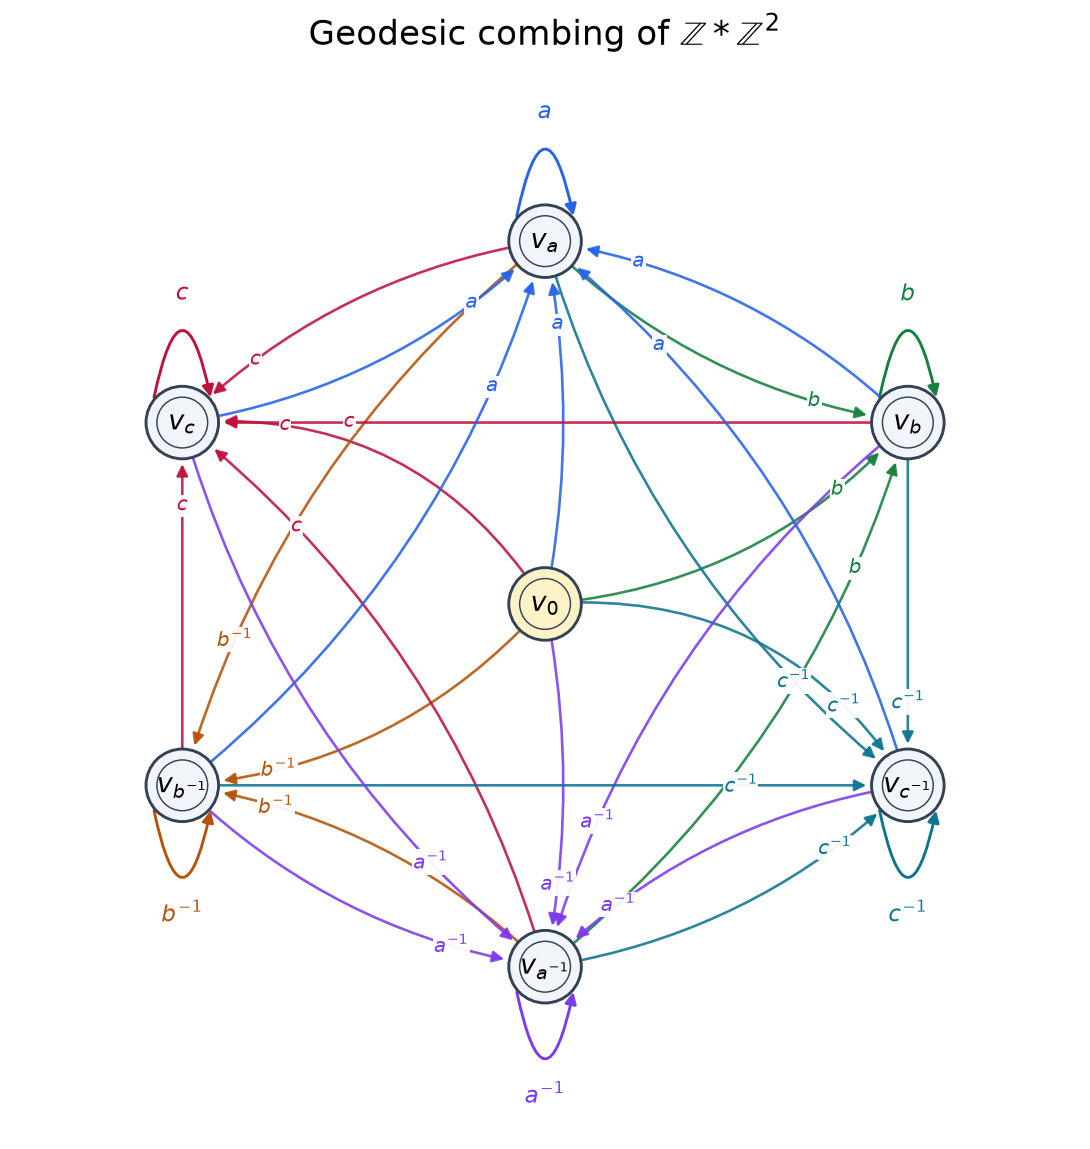

In [21]:
# A fixed layout keeps redraws reproducible. Labels sit near their arrow targets.
pos = {
    'v0': (0, 0),
    'v_a': (0, 1.5), 'v_A': (0, -1.5),
    'v_b': (1.5, 0.75), 'v_B': (-1.5, -0.75),
    'v_c': (-1.5, 0.75), 'v_C': (1.5, -0.75),
}
palette = {'a':'#2563eb', 'A':'#7c3aed', 'b':'#15803d', 'B':'#b45309', 'c':'#be123c', 'C':'#0e7490'}
fig, ax = plt.subplots(figsize=(15, 9))
radius = 0.15
for u, v, data in G.edges(data=True):
    s = data['label']
    p, q = np.asarray(pos[u], float), np.asarray(pos[v], float)
    color = palette[s]
    if u == v:
        sign = 1 if p[1] > 0 else -1
        start = p + np.array([-0.12, sign * 0.09])
        end   = p + np.array([ 0.12, sign * 0.09])
        # start = p + np.array([-0.16, sign * 0.20])
        # end = p + np.array([0.16, sign * 0.20])
        loop = FancyArrowPatch(start, end, connectionstyle=f'arc3,rad={-2.4 * sign}',
                               arrowstyle='-|>', mutation_scale=13, color=color, lw=1.6)
        ax.add_patch(loop)
        ax.text(p[0], p[1] + sign * 0.53, '$' + letter_tex[s] + '$',
                color=color, ha='center', va='center', fontsize=13)
    else:
        # For long initial edges, mild curves keep them away from intermediate nodes.
        rad = 0.16 if G.has_edge(v, u) else 0.0
        if u == 'v0':
            rad = (0.10 if q[1] > 0 else -0.10) * (1 + letters.index(s) // 2)
        edge = FancyArrowPatch(p, q, connectionstyle=f'arc3,rad={rad}',
                               arrowstyle='-|>', mutation_scale=13, color=color,
                               lw=1.45, alpha=0.88, shrinkA=21, shrinkB=23)
        ax.add_patch(edge)
        # Arc3 uses a quadratic Bezier with this control point in equal-aspect axes.
        delta = q - p
        control = (p + q) / 2 + rad * np.array([delta[1], -delta[0]])
        t = 0.77
        label_pos = (1-t)**2 * p + 2*(1-t)*t*control + t*t*q
        ax.text(*label_pos, '$' + letter_tex[s] + '$', color=color, fontsize=11,
                ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=0.6, alpha=0.94))
for v, (x, y) in pos.items():
    fill = '#fef3c7' if v == 'v0' else '#f1f5f9'
    ax.add_patch(Circle((x,y), radius, facecolor=fill, edgecolor='#334155', lw=1.6, zorder=5))
    ax.add_patch(Circle((x,y), radius-0.045, fill=False, edgecolor='#334155', lw=0.8, zorder=6))
    ax.text(x, y, '$' + state_tex[v] + '$', ha='center', va='center', fontsize=15, zorder=7)
# ax.annotate('', xy=(-0.5,0), xytext=(-1.5,0), arrowprops=dict(arrowstyle='-|>', color='#334155', lw=1.7)) # Just an arrow identifying v_0
ax.set(xlim=(-2.2,2.2), ylim=(-2.2,2.2), aspect='equal')
ax.set_title(r'Geodesic combing of $\mathbb{Z}*\mathbb{Z}^2$', fontsize=19, pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Adjacency matrix $M$

The state order is $(v_0,v_a,v_{\bar a},v_b,v_{\bar b},v_c,v_{\bar c})$, and $M_{ij}=1$ exactly when there is an edge from state $i$ to state $j$. The first column is zero because no edge enters $v_0$.

This is a $0$–$1$ adjacency matrix, not the stochastic matrix $N$.

In [22]:
M = nx.to_numpy_array(G, nodelist=states, dtype=int)
expected_M = np.array([
    [0,1,1,1,1,1,1],
    [0,1,0,1,1,1,1],
    [0,0,1,1,1,1,1],
    [0,1,1,1,0,1,1],
    [0,1,1,0,1,1,1],
    [0,1,1,0,0,1,0],
    [0,1,1,0,0,0,1],
])
assert np.array_equal(M, expected_M)
rows = [' & '.join(map(str, row)) for row in M]
display(Math(r'M=\begin{pmatrix}' + r'\\'.join(rows) + r'\end{pmatrix}'))
eigenvalues = sp.Matrix(M).eigenvals()
display(Math(sp.latex(eigenvalues)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Perron–Frobenius data and the vertex measure

Following [the manuscript definitions](../ordered_frequency_git/sections/geodesic_combings.tex), we use the exact Cesàro projections
$$
r=\lim_{n\to\infty}\frac1n\sum_{k=0}^{n}\lambda^{-k}M^k\mathbf1,
\qquad
\ell=\lim_{n\to\infty}\frac1n\sum_{k=0}^{n}\lambda^{-k}(M^T)^k\mathbf e_0.
$$
These definitions fix the scaling of $r$ and $\ell$; we do not normalize them to sum to one.
For this matrix, $\lambda$ is simple and strictly dominant, so the limits are computed exactly using the spectral projection $P=u v^T/(v^Tu)$: $r=P\mathbf1$ and $\ell=P^T\mathbf e_0$.

We then compute
$$
N_{ij}=\frac{M_{ij}r_j}{\lambda r_i}\quad(r_i>0),
\qquad
\mu_i=\frac{r_i\ell_i}{\sum_j r_j\ell_j}.
$$
When $r_i=0$, the $i$th row of $N$ is the $i$th identity row, as in the manuscript. All computations below use exact SymPy expressions. The vector `l` represents $\ell$, and all vectors use the same state order as $M$. The stationary vertex measure has $\mu_0=0$; it is distinct from the manuscript's based path measure $\mu^0$.


In [23]:
# Exact Cesaro projections from geodesic_combings.tex, followed by N and mu.
import sympy as sp
from IPython.display import display, Math

M_exact = sp.Matrix(M)
num_states = M_exact.rows
I = sp.eye(num_states)
ones = sp.ones(num_states, 1)
e0 = I[:, states.index('v0')]

# This M has real spectrum and a simple, strictly dominant PF eigenvalue.
pf_spectrum = M_exact.eigenvals()
assert all(value.is_real for value in pf_spectrum)
lam = max(pf_spectrum)
assert lam > 0 and pf_spectrum[lam] == 1
assert all(lam > sp.Abs(value) for value in pf_spectrum if value != lam)

# P = u v^T / (v^T u) is the exact spectral projection at lambda.
# Therefore P*1 and P.T*e0 equal the manuscript's Cesaro limits.
# Auxiliary eigenvectors u,v may have any nonzero scaling; r,l may not.
u = (M_exact - lam * I).nullspace()[0]
v = (M_exact.T - lam * I).nullspace()[0]
P = (u * v.T / v.dot(u)).applyfunc(sp.simplify)
r = (P * ones).applyfunc(sp.simplify)
l = (P.T * e0).applyfunc(sp.simplify)

# Preserve the manuscript's absorbing-row convention when r_i = 0.
assert all(value >= 0 for value in r)
assert all(value >= 0 for value in l)
N = sp.zeros(num_states)
for i in range(num_states):
    if r[i] == 0:
        N[i, i] = 1
    else:
        for j in range(num_states):
            N[i, j] = sp.simplify(M_exact[i, j] * r[j] / (lam * r[i]))

mu_weights = r.multiply_elementwise(l)
mu = (mu_weights / sum(mu_weights)).applyfunc(sp.simplify)

# Exact identities, rather than floating-point tolerance checks.
assert (P * P - P).applyfunc(sp.simplify) == sp.zeros(num_states)
assert (M_exact * r - lam * r).applyfunc(sp.simplify) == sp.zeros(num_states, 1)
assert (M_exact.T * l - lam * l).applyfunc(sp.simplify) == sp.zeros(num_states, 1)
assert (N * ones - ones).applyfunc(sp.simplify) == sp.zeros(num_states, 1)
assert (N.T * mu - mu).applyfunc(sp.simplify) == sp.zeros(num_states, 1)
assert sp.simplify(sum(mu)) == 1
assert all(value >= 0 for value in N) and all(value >= 0 for value in mu)

display(Math(r'\text{State order: }\quad(' + ','.join(state_tex[s] for s in states) + ')'))
display(Math(r'\lambda=' + sp.latex(lam)))
display(Math(r'r=' + sp.latex(r) + r'\qquad\ell=' + sp.latex(l)))
display(Math(r'N=' + sp.latex(N)))
display(Math(r'(\mu_i)_i=' + sp.latex(mu)))
print('Exact checks passed: PF equations, stochasticity, and stationarity of mu.')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Exact checks passed: PF equations, stochasticity, and stationarity of mu.


## 4. The component quotient $C(\mathcal{G})$

All six noninitial states are mutually reachable. Each can reach $v_a$, and $v_a$ can reach each of them. The only cases requiring two steps are
$ v_{\bar a}\xrightarrow{b}v_b\xrightarrow{a}v_a $
and $v_a\xrightarrow{b}v_b\xrightarrow{\bar a}v_{\bar a}$.

Thus $C_0=\{v_0\}$ and $C_1=\{v_a,v_{\bar a},v_b,v_{\bar b},v_c,v_{\bar c}\}$.
The condensation identifies each component with one vertex, drops internal edges, and merges the six initial edges into one arrow. It therefore has no loops and does not retain generator labels.

Quotient adjacency in order (C0, C1):
[[0 1]
 [0 0]]


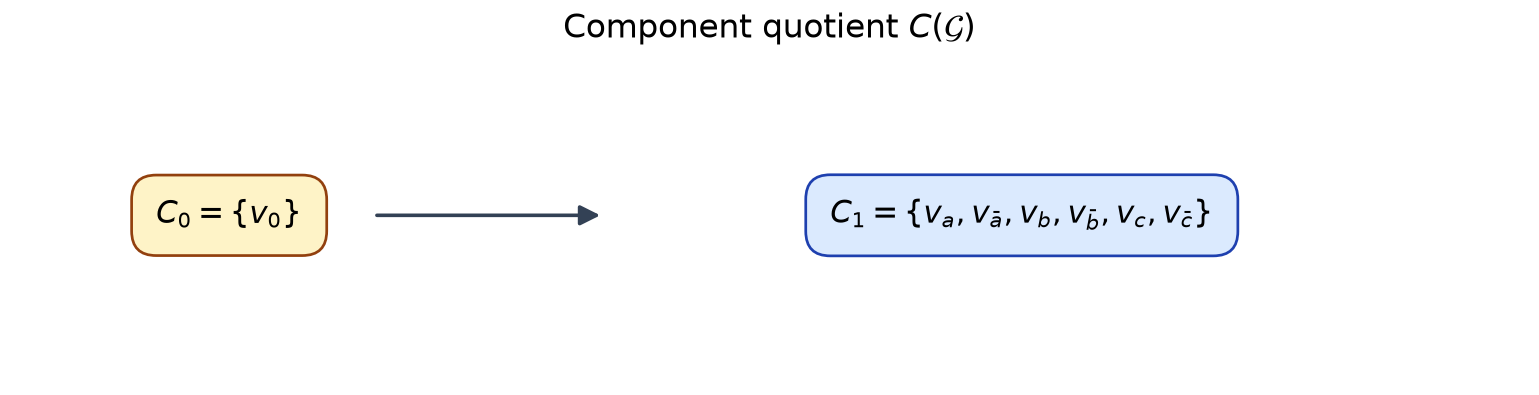

In [24]:
# Supply the SCCs in the desired order, instead of relying on NetworkX's order.
components = sorted(nx.strongly_connected_components(G), key=lambda comp: min(idx[v] for v in comp))
Q = nx.condensation(G, scc=components)
assert components == [{'v0'}, set(states[1:])]
assert set(Q.edges()) == {(0,1)}
M_quotient = nx.to_numpy_array(Q, nodelist=[0,1], dtype=int)
print('Quotient adjacency in order (C0, C1):')
print(M_quotient)

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.text(0.15, 0.5, r'$C_0=\{v_0\}$', ha='center', va='center', fontsize=17,
        bbox=dict(boxstyle='round,pad=0.8', fc='#fef3c7', ec='#92400e', lw=1.5))
ax.text(0.70, 0.5, r'$C_1=\{v_a,v_{\bar a},v_b,v_{\bar b},v_c,v_{\bar c}\}$',
        ha='center', va='center', fontsize=17,
        bbox=dict(boxstyle='round,pad=0.8', fc='#dbeafe', ec='#1e40af', lw=1.5))
ax.annotate('', xy=(0.41,0.5), xytext=(0.25,0.5),
            arrowprops=dict(arrowstyle='-|>', mutation_scale=23, lw=2, color='#334155'))
ax.set(xlim=(0,1.05), ylim=(0,1))
ax.set_title(r'Component quotient $C(\mathcal{G})$', fontsize=18)
ax.axis('off')
plt.tight_layout()
plt.show()

### Exact data for the maximal component

Let $C=C_1$ be the component containing the six generator states, in the order inherited from $M$. Its adjacency matrix $M_C$ is the corresponding $6\times6$ principal submatrix of $M$. Its spectral radius satisfies $\lambda_C=\lambda=2+\sqrt5$, so $C$ is maximal.

Using the same Cesàro-projection convention,
$$
r_C=\lim_{n\to\infty}\frac1n\sum_{k=0}^n\lambda_C^{-k}M_C^k\mathbf1_C,
\qquad
(N_C)_{ij}=\frac{(M_C)_{ij}(r_C)_j}{\lambda_C(r_C)_i}.
$$
All entries of $r_C$ are positive. Since $C$ has no outgoing edges to other components, $N_C$ also equals the restriction of $N$ to these six states. Run the full-graph Perron–Frobenius cell above before this cell.


In [25]:
# Exact PF data on the six-state maximal component C = C_1.
import sympy as sp
from IPython.display import display, Math

component_C = next(comp for comp in nx.strongly_connected_components(G) if 'v_a' in comp)
states_C = [state for state in states if state in component_C]
indices_C = [states.index(state) for state in states_C]
M_C = sp.Matrix(M).extract(indices_C, indices_C)
size_C = M_C.rows
spectrum_C = M_C.eigenvals()
lam_C = max(spectrum_C)
assert spectrum_C[lam_C] == 1 and sp.simplify(lam_C - lam) == 0

# The same Cesaro-projection convention, now applied to M_C and 1_C.
u_C = (M_C - lam_C * sp.eye(size_C)).nullspace()[0]
v_C = (M_C.T - lam_C * sp.eye(size_C)).nullspace()[0]
P_C = (u_C * v_C.T / v_C.dot(u_C)).applyfunc(sp.simplify)
r_C = (P_C * sp.ones(size_C, 1)).applyfunc(sp.simplify)
assert all(value > 0 for value in r_C)
N_C = sp.Matrix(size_C, size_C,
                lambda i, j: sp.simplify(M_C[i, j] * r_C[j] / (lam_C * r_C[i])))

# C is terminal: its stochastic matrix agrees with the restriction of N.
assert (M_C * r_C - lam_C * r_C).applyfunc(sp.simplify) == sp.zeros(size_C, 1)
assert (N_C * sp.ones(size_C, 1) - sp.ones(size_C, 1)).applyfunc(sp.simplify) == sp.zeros(size_C, 1)
assert all(value >= 0 for value in N_C)
assert (N_C - N.extract(indices_C, indices_C)).applyfunc(sp.simplify) == sp.zeros(size_C)

display(Math(r'\text{Component state order: }\quad(' + ','.join(state_tex[s] for s in states_C) + ')'))
display(Math(r'M_C=' + sp.latex(M_C)))
display(Math(r'\lambda_C=' + sp.latex(lam_C)))
display(Math(r'N_C=' + sp.latex(N_C)))
print('Exact checks passed: lambda_C = lambda, N_C is stochastic, and N_C is the restriction of N to C.')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Exact checks passed: lambda_C = lambda, N_C is stochastic, and N_C is the restriction of N to C.


## 5. Why this is a geodesic combing

Every element of a free product has a unique reduced factor normal form: an alternating sequence of nonidentity syllables from $\mathbb{Z}$ and $\mathbb{Z}^2$. Represent each $\mathbb{Z}$ syllable by $a^k$ with $k\ne0$, and each $\mathbb{Z}^2$ syllable by $b^m c^n$ with $(m,n)\ne(0,0)$. Negative powers mean repeated inverse letters.

The transition rules accept exactly these concatenations, including the empty word. The factor normal form and the fixed order $b^m c^n$ give **bijective evaluation** from paths starting at $v_0$ to group elements. Distinct outgoing labels make the path determined by its word.

Each factor syllable has minimum length: $|k|$ in $\mathbb{Z}$, or $|m|+|n|$ in $\mathbb{Z}^2$. Reducing any representative to its factor normal form cannot increase length. Our chosen word achieves the sum of these minimum syllable lengths and is therefore **geodesic**.

Every prefix is again accepted, so this is a prefix-closed regular language. Every state is reachable from $v_0$; consequently any finite path in the graph can be extended backwards to a path starting at $v_0$. Its word is a suffix of a geodesic word and is itself geodesic.

The statements above prove the properties in all lengths; the finite check below checks the implementation independently against group multiplication.

In [26]:
def word_path(word):
    """Return the state path from v0; reject words outside the combing."""
    path = ['v0']
    for s in word:
        if s not in allowed[path[-1]]:
            raise ValueError(f'No transition from {path[-1]} labeled {s!r}')
        path.append('v_' + s)
    return path


def multiply_letter(normal_form, letter):
    """Right multiplication using reduced free-product syllables, independent of G."""
    syllables = list(normal_form)
    piece = {'a': ('Z',1,0), 'A': ('Z',-1,0),
             'b': ('Z2',1,0), 'B': ('Z2',-1,0),
             'c': ('Z2',0,1), 'C': ('Z2',0,-1)}[letter]
    factor, x, y = piece
    if syllables and syllables[-1][0] == factor:
        _, u, v = syllables.pop()
        x, y = x + u, y + v
    if x or y:
        syllables.append((factor,x,y))
    return tuple(syllables)


def evaluate(word):
    result = ()
    for letter in word:
        result = multiply_letter(result, letter)
    return result

# Compare graph paths of length n with independent Cayley-graph BFS spheres.
max_length = 6
seen = {()}
sphere = {()}
paths = [('', 'v0')]
counts = []
for n in range(max_length + 1):
    evaluations = [evaluate(word) for word, _ in paths]
    assert len(evaluations) == len(set(evaluations)), f'Duplicate at length {n}'
    assert set(evaluations) == sphere, f'Missing or nongeodesic word at length {n}'
    counts.append(len(sphere))
    next_sphere = {multiply_letter(g,s) for g in sphere for s in letters} - seen
    seen.update(next_sphere)
    sphere = next_sphere
    paths = [(word+s, target) for word, state in paths for s, target in transitions[state]]
# assert counts == [1,6,26,110,466,1974,8362]
assert evaluate('bc') == evaluate('cb')
assert word_path('bc') == ['v0','v_b','v_c']
try:
    word_path('cb')
except ValueError:
    pass
else:
    raise AssertionError('cb should not be accepted')
print(f'Verified: exact matrix, two SCCs, and bijective geodesic paths through length {max_length}.')
print(f'Sphere sizes for lengths 0–{max_length}:', counts)
print('Total elements checked:', sum(counts))

Verified: exact matrix, two SCCs, and bijective geodesic paths through length 6.
Sphere sizes for lengths 0–6: [1, 6, 26, 110, 466, 1974, 8362]
Total elements checked: 10945


## 6. A finite Cayley graph with the combing highlighted

This is the induced word-metric ball of radius `cayley_radius` for the generators $a^{\pm1},b^{\pm1},c^{\pm1}$. Group multiplication is computed using reduced free-product syllables. It includes every Cayley edge with both endpoints in the ball; each undirected edge represents a generator and its inverse.

Each shaded diamond is part of a coset $g\langle b,c\rangle$, drawn as a square lattice with $b$ horizontal and $c$ vertical. Blue and amber edges join these pieces: blue reads $a$ and amber reads $a^{-1}$ in the outward ray direction. Collapsing each piece gives a tree. Pieces near the boundary may contain only five vertices or a single vertex, because the picture is truncated by word length.

Solid colored edges form the spanning tree selected by the combing, with arrows pointing away from the identity along its geodesic rays. Dashed grey edges are the remaining Cayley edges and have no combing direction. Within each grid piece the combing follows $b$ first, then $c$. The separate close-up shows this pattern in the identity grid. The star marks the identity. Crossings of drawn edges are not additional vertices, and plotted edge lengths do not represent word distances.

The default radius is three (143 vertices). Change `cayley_radius` near the top of the cell to enlarge or shrink the ball. Only the transition-definition cell is required before running this plot.


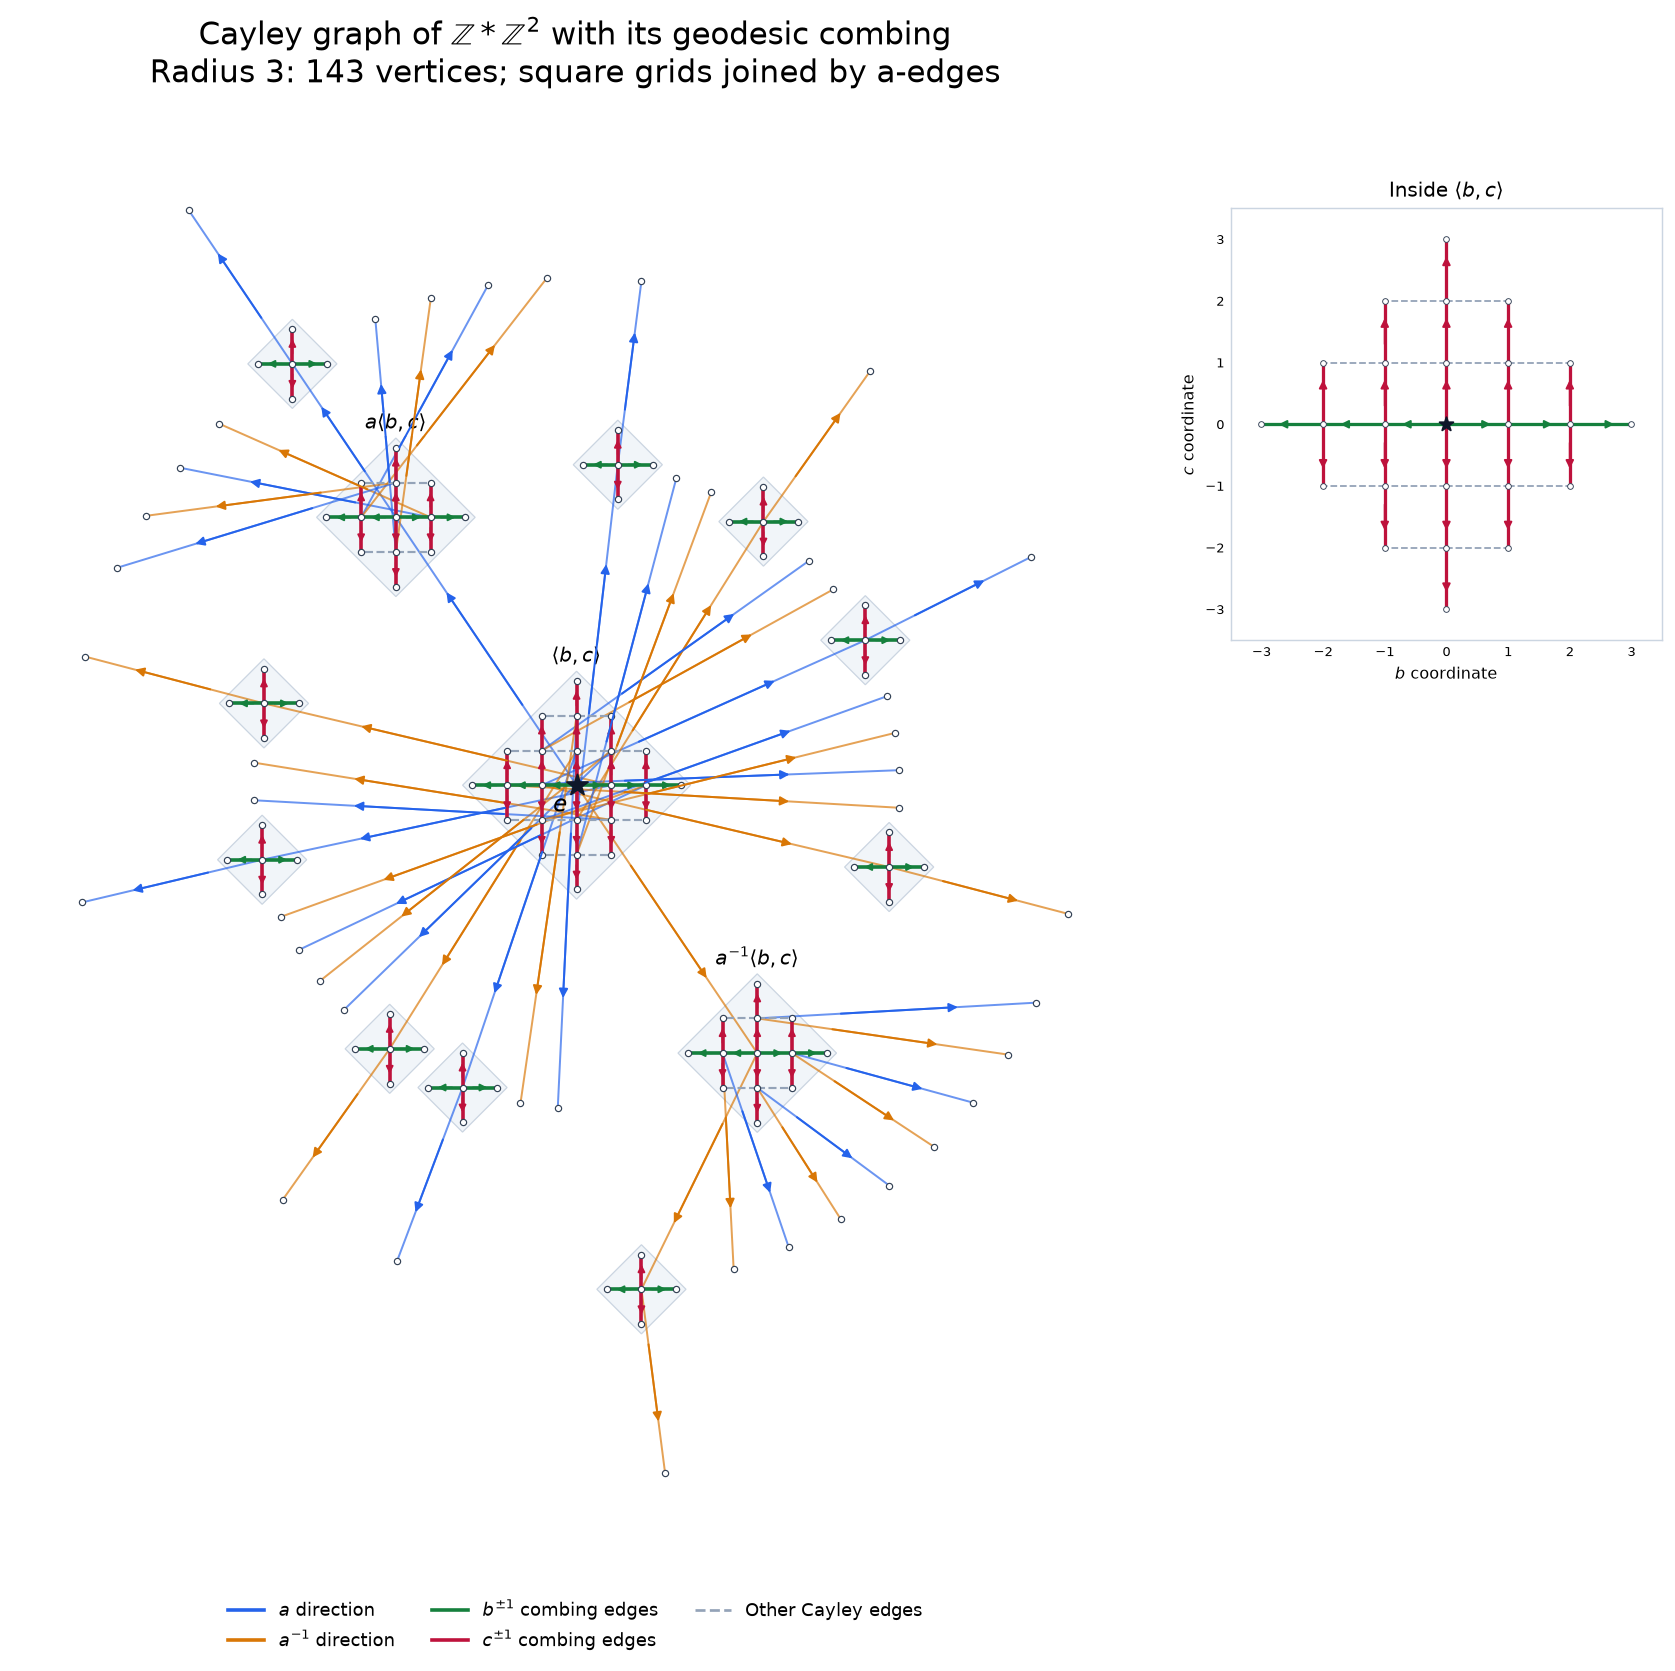

143 vertices, 162 Cayley edges, 142 combing edges, 55 grid pieces.


In [27]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon, FancyArrowPatch

# Radius 3 gives 143 vertices. Radius 4 gives 609 and is considerably denser.
cayley_radius = 3
assert isinstance(cayley_radius, int) and cayley_radius >= 1

def cayley_multiply(g, letter):
    """Multiply reduced free-product syllables by one generator on the right."""
    increments = {'a': ('Z', 1, 0), 'A': ('Z', -1, 0),
                  'b': ('Z2', 1, 0), 'B': ('Z2', -1, 0),
                  'c': ('Z2', 0, 1), 'C': ('Z2', 0, -1)}
    result = list(g)
    factor, x, y = increments[letter]
    if result and result[-1][0] == factor:
        _, old_x, old_y = result.pop()
        x, y = x + old_x, y + old_y
    if x or y:
        result.append((factor, x, y))
    return tuple(result)

def cayley_word(g):
    """The selected geodesic: constant-sign a runs and ordered b^m c^n blocks."""
    word = ''
    for factor, x, y in g:
        if factor == 'Z':
            word += ('a' if x >= 0 else 'A') * abs(x)
        else:
            word += ('b' if x >= 0 else 'B') * abs(x)
            word += ('c' if y >= 0 else 'C') * abs(y)
    return word

# BFS in the actual group, then include ALL edges internal to the ball.
cayley_distance = {(): 0}
frontier = [()]
for depth in range(cayley_radius):
    next_frontier = []
    for g in frontier:
        for letter in 'aAbBcC':
            h = cayley_multiply(g, letter)
            if h not in cayley_distance:
                cayley_distance[h] = depth + 1
                next_frontier.append(h)
    frontier = next_frontier
cayley_ball = nx.Graph()
cayley_ball.add_nodes_from(cayley_distance)
for g in cayley_distance:
    for letter in 'abc':
        h = cayley_multiply(g, letter)
        if h in cayley_distance:
            cayley_ball.add_edge(g, h, generator=letter)

# Extract the spanning combing tree by reading canonical words in the automaton.
combing_tree = nx.Graph()
combing_tree.add_nodes_from(cayley_ball)
for g, distance in cayley_distance.items():
    word = cayley_word(g)
    assert len(word) == distance
    current, state = (), 'v0'
    for letter in word:
        state = dict(transitions[state])[letter]
        following = cayley_multiply(current, letter)
        assert cayley_ball.has_edge(current, following)
        combing_tree.add_edge(current, following)
        current = following
    assert current == g
assert nx.is_tree(combing_tree)

# A flat is a left coset g< b,c >. Removing the last Z2 syllable gives its key.
def cayley_flat(g):
    return g[:-1] if g and g[-1][0] == 'Z2' else g

flat_vertices = {}
local_coordinates = {}
for g in cayley_ball:
    flat_vertices.setdefault(cayley_flat(g), []).append(g)
    local_coordinates[g] = np.array(g[-1][1:] if g and g[-1][0] == 'Z2' else (0, 0))
flat_tree = nx.Graph()
flat_tree.add_nodes_from(flat_vertices)
for g, h, data in cayley_ball.edges(data=True):
    if data['generator'] == 'a':
        flat_tree.add_edge(cayley_flat(g), cayley_flat(h))
    else:
        assert cayley_flat(g) == cayley_flat(h)
assert nx.is_tree(flat_tree)

# Allocate angular sectors to flat subtrees, keeping each grid rigid.
flat_order = list(nx.bfs_tree(flat_tree, ()))
flat_children = {f: [] for f in flat_order}
flat_level = {(): 0}
for parent, child in nx.bfs_edges(flat_tree, ()):
    flat_children[parent].append(child)
    flat_level[child] = flat_level[parent] + 1
grid_spacing = 0.60
flat_radius = {f: grid_spacing * max(np.abs(local_coordinates[g]).sum() for g in nodes)
               for f, nodes in flat_vertices.items()}
sector_weight = {}
for f in reversed(flat_order):
    flat_children[f].sort(key=cayley_word)
    sector_weight[f] = max(1 + 2 * flat_radius[f],
                           sum(sector_weight[ch] for ch in flat_children[f]))
flat_center = {(): np.zeros(2)}
sector = {(): (-np.pi / 2, 3 * np.pi / 2)}
base_ring = max(5.5, sector_weight[()] / (2 * np.pi) * 0.65)
for f in flat_order:
    low, high = sector[f]
    total = sum(sector_weight[ch] for ch in flat_children[f])
    cursor = low
    for ch in flat_children[f]:
        width = (high - low) * sector_weight[ch] / total
        sector[ch] = (cursor, cursor + width)
        angle = cursor + width / 2
        ring = base_ring + 3.2 * (flat_level[ch] - 1)
        flat_center[ch] = ring * np.array([np.cos(angle), np.sin(angle)])
        cursor += width
cayley_pos = {g: flat_center[cayley_flat(g)] + grid_spacing * local_coordinates[g]
              for g in cayley_ball}

def add_ray_arrow(axis, g, h, positions, color, size=9):
    # Orient by word distance, not by the endpoints' order or screen positions.
    if cayley_distance[g] > cayley_distance[h]:
        g, h = h, g
    start = np.asarray(positions[g], dtype=float)
    direction = np.asarray(positions[h], dtype=float) - start
    axis.add_patch(FancyArrowPatch(start + 0.30 * direction, start + 0.72 * direction,
                                  arrowstyle='-|>', mutation_scale=size, lw=1.1,
                                  shrinkA=0, shrinkB=0, color=color, zorder=4))

fig, ax = plt.subplots(figsize=(15, 13))
for f, center in flat_center.items():
    extent = flat_radius[f]
    if extent:
        hull = center + (extent + 0.17) * np.array([(1, 0), (0, 1), (-1, 0), (0, -1)])
        ax.add_patch(Polygon(hull, fc='#f1f5f9', ec='#cbd5e1', lw=0.7, zorder=0))
edge_colors = {'a': '#2563eb', 'A': '#d97706', 'b': '#15803d', 'c': '#be123c'}

def combing_edge_color(g, h):
    # Classify the letter read away from the identity, including its sign.
    if cayley_distance[g] > cayley_distance[h]:
        g, h = h, g
    generator = cayley_ball[g][h]['generator']
    if generator == 'a' and cayley_multiply(g, 'A') == h:
        return edge_colors['A']
    return edge_colors[generator]

for generator in 'abc':
    for in_combing in [False, True]:
        selected_edges = [(g, h) for g, h, d in cayley_ball.edges(data=True)
                          if d['generator'] == generator and combing_tree.has_edge(g, h) == in_combing]
        segments = [(cayley_pos[g], cayley_pos[h]) for g, h in selected_edges]
        if segments:
            ax.add_collection(LineCollection(segments,
                colors=[combing_edge_color(g, h) for g, h in selected_edges] if in_combing else '#94a3b8',
                linewidths=(1.1 if generator == 'a' else 2.0) if in_combing else 1.2,
                linestyles='solid' if in_combing else 'dashed',
                alpha=0.68 if generator == 'a' else 1.0, zorder=1 if generator == 'a' else 2))
# Arrowheads on every combing edge indicate the direction of geodesic rays.
for g, h in combing_tree.edges():
    generator = cayley_ball[g][h]['generator']
    add_ray_arrow(ax, g, h, cayley_pos, combing_edge_color(g, h),
                  size=10 if generator == 'a' else 8)
ordered_vertices = list(cayley_ball)
xy = np.array([cayley_pos[g] for g in ordered_vertices])
ax.scatter(xy[:, 0], xy[:, 1], s=12, facecolors='white', edgecolors='#334155', lw=0.65, zorder=3)
ax.scatter([0], [0], marker='*', s=150, color='#0f172a', zorder=5)
ax.annotate('$e$', (0, 0), xytext=(-13, -15), textcoords='offset points', fontsize=13)
for word, label in [('', r'$\langle b,c\rangle$'), ('a', r'$a\langle b,c\rangle$'),
                    ('A', r'$a^{-1}\langle b,c\rangle$')]:
    key = () if not word else cayley_multiply((), word)
    center = flat_center[key]
    ax.text(center[0], center[1] + flat_radius[key] + 0.32, label,
            ha='center', fontsize=11, bbox=dict(fc='white', ec='none', pad=1))
ax.set_title(r'Cayley graph of $\mathbb{Z}*\mathbb{Z}^2$ with its geodesic combing'
             + f'\nRadius {cayley_radius}: {len(cayley_ball)} vertices; square grids joined by a-edges',
             fontsize=17, pad=22)
legend = [Line2D([0], [0], color=edge_colors['a'], lw=2, label=r'$a$ direction'),
          Line2D([0], [0], color=edge_colors['A'], lw=2, label=r'$a^{-1}$ direction'),
          Line2D([0], [0], color=edge_colors['b'], lw=2, label=r'$b^{\pm1}$ combing edges'),
          Line2D([0], [0], color=edge_colors['c'], lw=2, label=r'$c^{\pm1}$ combing edges')]
legend.append(Line2D([0], [0], color='#94a3b8', ls='--', lw=1.5, label='Other Cayley edges'))
ax.legend(handles=legend, loc='upper center', bbox_to_anchor=(0.5, -0.015),
          ncol=3, frameon=False, fontsize=10)
ax.set_aspect('equal')
ax.autoscale_view()
ax.margins(0.07)
ax.axis('off')
# An unobstructed close-up makes the square lattice and omitted edges clear.
detail_ax = ax.inset_axes([1.06, 0.64, 0.43, 0.30], zorder=10)
detail_ax.set_facecolor('white')
for g, h, data in cayley_ball.edges(data=True):
    if cayley_flat(g) == () and cayley_flat(h) == ():
        in_tree = combing_tree.has_edge(g, h)
        points = np.array([local_coordinates[g], local_coordinates[h]])
        detail_ax.plot(points[:, 0], points[:, 1],
                       color=edge_colors[data['generator']] if in_tree else '#94a3b8',
                       lw=1.8 if in_tree else 1.0, ls='-' if in_tree else '--')
for g, h in combing_tree.edges():
    if cayley_flat(g) == () and cayley_flat(h) == ():
        generator = cayley_ball[g][h]['generator']
        add_ray_arrow(detail_ax, g, h, local_coordinates, edge_colors[generator], size=9)
root_points = np.array([local_coordinates[g] for g in flat_vertices[()]])
detail_ax.scatter(root_points[:, 0], root_points[:, 1], s=10,
                  facecolors='white', edgecolors='#334155', lw=0.5, zorder=3)
detail_ax.scatter([0], [0], marker='*', s=65, color='#0f172a', zorder=4)
detail_ax.set(xlim=(-cayley_radius - 0.5, cayley_radius + 0.5),
              ylim=(-cayley_radius - 0.5, cayley_radius + 0.5), aspect='equal')
detail_ax.set_title(r'Inside $\langle b,c\rangle$', fontsize=11)
detail_ax.set_xlabel('$b$ coordinate', fontsize=9)
detail_ax.set_ylabel('$c$ coordinate', fontsize=9)
detail_ax.set_xticks(range(-cayley_radius, cayley_radius + 1))
detail_ax.set_yticks(range(-cayley_radius, cayley_radius + 1))
detail_ax.tick_params(labelsize=7, length=0)
for spine in detail_ax.spines.values():
    spine.set_color('#cbd5e1')
fig.tight_layout()
plt.show()
print(f'{len(cayley_ball)} vertices, {cayley_ball.number_of_edges()} Cayley edges, '
      f'{combing_tree.number_of_edges()} combing edges, {len(flat_tree)} grid pieces.')


## References and conventions

- Calegari–Fujiwara (2010), Definition 2.13, p. 1349: a combing is a prefix-closed regular language with bijective evaluation to the group, consisting of geodesics. See also §2.3 for the component graph. Local file: [calagari_fujiwara_2010.pdf](../ordered_frequency/references/calagari_fujiwara_2010.pdf).
- GTT20, §3.1, pp. 324–325: labeled graph structures, geodesicity, and bijective evaluation of paths from the initial vertex. Local file: [GTT20.pdf](../ordered_frequency/references/GTT20.pdf).

Here “quotient” means the pointed component graph. NetworkX includes the acyclic singleton $\{v_0\}$ as an SCC; the Calegari–Fujiwara convention retains cyclic components and adjoins the initial vertex. Both give $C_0\to C_1$ in this example. The construction above uses free-product normal forms directly.